In [62]:
import prophet
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
os.listdir('..')

['lib', 'input', 'working']

In [37]:
info = pd.read_csv('../input/timeseries/preprocessed.csv')
info['month_trunc'] = pd.to_datetime(info['month_trunc'])
info

,year,month,month_trunc,sub-category,quantity
0,2014,1,2014-01-01,Accessories,50
1,2014,1,2014-01-01,Tables,22
2,2014,1,2014-01-01,Supplies,68
3,2014,1,2014-01-01,Storage,167
4,2014,1,2014-01-01,Phones,73
...,...,...,...,...,...
811,2017,12,2017-12-01,Appliances,322
812,2017,12,2017-12-01,Accessories,468
813,2017,12,2017-12-01,Supplies,410
814,2017,12,2017-12-01,Envelopes,343


In [52]:
from prophet import Prophet

cats = info['sub-category'].unique()
prophet_dfs = dict()
index_75_percent = len(info) * 3 // 4
cat_to_forecast = dict()

for cat in cats:
    prophet_dfs[cat] = info.iloc[:index_75_percent ][info.iloc[:index_75_percent]['sub-category'] == cat][['month_trunc', 'quantity']].copy()
    prophet_dfs[cat].rename(columns={'month_trunc': 'ds', 'quantity': 'y'}, inplace=True)
    prophet_dfs[cat]['ds'] = pd.to_datetime(prophet_dfs[cat]['ds'])
    prophet_dfs[cat].sort_values('ds', inplace=True)

    model = Prophet(
        growth="linear",
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative'
    )
    model.fit(prophet_dfs[cat], algorithm='newton')
    n = 20
    future = model.make_future_dataframe(periods=n, freq='MS')
    forecast = model.predict(future)
    forecast['is_train'] = [True] * len(prophet_dfs[cat]) + [False] * n
    cat_to_forecast[cat] = forecast

10:47:16 - cmdstanpy - INFO - Chain [1] start processing
10:47:17 - cmdstanpy - INFO - Chain [1] done processing
10:47:17 - cmdstanpy - INFO - Chain [1] start processing
10:47:17 - cmdstanpy - INFO - Chain [1] done processing
10:47:17 - cmdstanpy - INFO - Chain [1] start processing
10:47:17 - cmdstanpy - INFO - Chain [1] done processing
10:47:17 - cmdstanpy - INFO - Chain [1] start processing
10:47:17 - cmdstanpy - INFO - Chain [1] done processing
10:47:17 - cmdstanpy - INFO - Chain [1] start processing
10:47:18 - cmdstanpy - INFO - Chain [1] done processing
10:47:18 - cmdstanpy - INFO - Chain [1] start processing
10:47:18 - cmdstanpy - INFO - Chain [1] done processing
10:47:18 - cmdstanpy - INFO - Chain [1] start processing
10:47:18 - cmdstanpy - INFO - Chain [1] done processing
10:47:18 - cmdstanpy - INFO - Chain [1] start processing
10:47:18 - cmdstanpy - INFO - Chain [1] done processing
10:47:18 - cmdstanpy - INFO - Chain [1] start processing
10:47:18 - cmdstanpy - INFO - Chain [1]

In [19]:
future = model.make_future_dataframe(periods=10, freq='MS')

forecast = model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-01-01,183.51256,23.592212,172.965203,183.51256,183.51256,-82.665396,-82.665396,-82.665396,-82.665396,-82.665396,-82.665396,0.0,0.0,0.0,100.847164
1,2014-02-01,183.51256,27.743069,174.030703,183.51256,183.51256,-84.229758,-84.229758,-84.229758,-84.229758,-84.229758,-84.229758,0.0,0.0,0.0,99.282802
2,2014-03-01,183.51256,67.409445,213.965929,183.51256,183.51256,-46.669044,-46.669044,-46.669044,-46.669044,-46.669044,-46.669044,0.0,0.0,0.0,136.843516
3,2014-04-01,183.51256,73.425110,217.870042,183.51256,183.51256,-37.050331,-37.050331,-37.050331,-37.050331,-37.050331,-37.050331,0.0,0.0,0.0,146.462229
4,2014-05-01,183.51256,86.913259,238.932390,183.51256,183.51256,-20.184890,-20.184890,-20.184890,-20.184890,-20.184890,-20.184890,0.0,0.0,0.0,163.327670
5,2014-06-01,183.51256,158.736922,312.705114,183.51256,183.51256,54.695715,54.695715,54.695715,54.695715,54.695715,54.695715,0.0,0.0,0.0,238.208275
6,2014-07-01,183.51256,56.014007,199.911410,183.51256,183.51256,-53.281366,-53.281366,-53.281366,-53.281366,-53.281366,-53.281366,0.0,0.0,0.0,130.231194
7,2014-08-01,183.51256,148.622212,293.285257,183.51256,183.51256,38.245734,38.245734,38.245734,38.245734,38.245734,38.245734,0.0,0.0,0.0,221.758294
8,2014-09-01,183.51256,157.452830,309.614080,183.51256,183.51256,53.039748,53.039748,53.039748,53.039748,53.039748,53.039748,0.0,0.0,0.0,236.552308
9,2014-10-01,183.51256,167.468758,315.951315,183.51256,183.51256,60.538185,60.538185,60.538185,60.538185,60.538185,60.538185,0.0,0.0,0.0,244.050745


,train_mae,train_mape,train_rmse,test_mae,test_mape,test_rmse
Accessories,11.093680,0.069970,43.638193,32.109930,0.120551,43.638193
Tables,7.619770,0.185319,32.052210,26.033972,0.322280,32.052210
Supplies,10.730063,0.081342,58.574814,45.785896,0.206012,58.574814
Storage,20.892873,0.073676,78.204563,67.078831,0.145467,78.204563
Phones,20.199357,0.096283,65.619383,48.994945,0.152388,65.619383
Machines,9.624477,0.133135,44.156322,36.945638,0.246805,44.156322
Labels,21.094370,0.170170,56.038601,44.944376,0.225062,56.038601
Furnishings,16.302407,0.091432,33.900579,29.022783,0.104242,33.900579
Paper,22.160579,0.110514,74.265492,57.703271,0.244647,74.265492
Envelopes,11.465203,0.096610,49.949954,38.971571,0.198646,49.949954


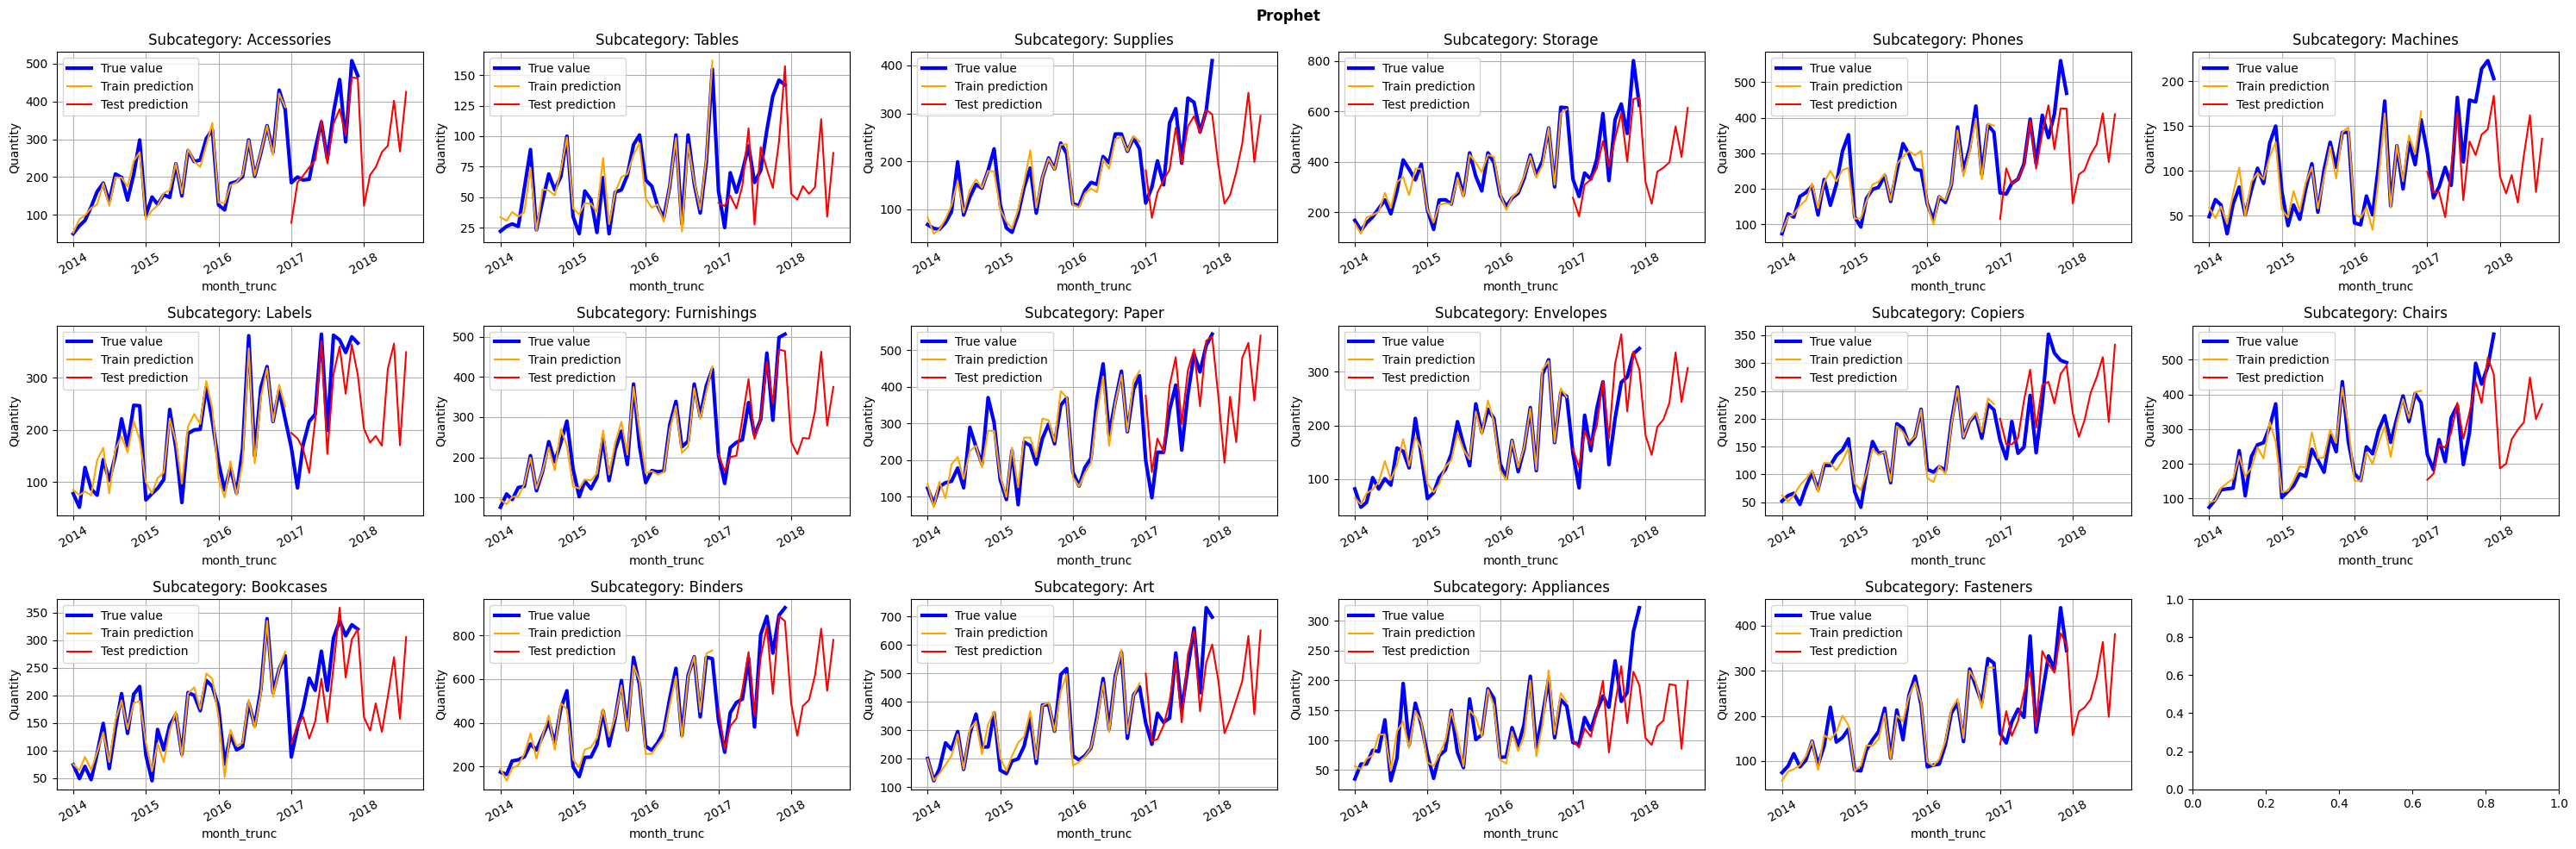

In [92]:
import warnings
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.metrics import mean_squared_error as MSE
warnings.filterwarnings('ignore')

ts_column = 'month_trunc'
fig, axes = plt.subplots(len(cats) // 6 + (len(cats) % 6 != 0) , 6, figsize=(30, 10))
plt.suptitle('Prophet', weight='bold')
for subcategory, ax in zip(cats, axes.flatten()):
    sns.lineplot(
        data=info[info['sub-category'] == subcategory],
        x=ts_column,
        y='quantity',
        ax=ax,
        label='True value',
        color='blue',
        linewidth=3
    )
    sns.lineplot(
        data=cat_to_forecast[subcategory][cat_to_forecast[subcategory].is_train],
        x='ds',
        y='yhat',
        ax=ax,
        label='Train prediction',
        color='orange'
    )
    sns.lineplot(
        data=cat_to_forecast[subcategory][~cat_to_forecast[subcategory].is_train],
        x='ds',
        y='yhat',
        ax=ax,
        label='Test prediction',
        color='red'
    )
    ax.set_ylabel('Quantity')
    for label in ax.get_xticklabels():
        label.set_rotation(30)
    ax.set_title(f'Subcategory: {subcategory}')
    ax.grid()
    ax.legend()

# for metric, metric_name in zip([MAE, MAPE, MSE], ['MAE', 'MAPE', 'MSE']):
#     print(f'Overall train {metric_name}:', round(metric(train.iloc[-train_preds.shape[0]:], train_preds), 2))
#     print(f'Overall test {metric_name}:', round(metric(test, test_preds), 2))

train_mae, test_mae, train_mape, test_mape, train_rmse, test_rmse = [[] for _ in range(6)]
metric_lists = [(train_mae, test_mae), (train_mape, test_mape), (train_rmse, test_rmse)]
for subcategory in cats:
    merged = pd.merge(
        info[info['sub-category'] == subcategory], 
        cat_to_forecast[subcategory][['ds', 'yhat', 'is_train']],
        left_on='month_trunc', 
        right_on='ds'
    )
    for metric, (train_list, test_list) in zip([MAE, MAPE, MSE], metric_lists):
        train_list.append(metric(merged[merged.is_train]['quantity'], merged[merged.is_train]['yhat']))
        test_list.append(metric(merged[~merged.is_train]['quantity'], merged[~merged.is_train]['yhat']))


results = pd.DataFrame({
        'train_mae': train_mae,
        'train_mape': train_mape,
        'train_rmse': np.sqrt(test_rmse),
        'test_mae': test_mae,
        'test_mape': test_mape,
        'test_rmse': np.sqrt(test_rmse)
    }, 
    index=cats
)
display(results)
fig.tight_layout()
plt.show()

11:26:47 - cmdstanpy - INFO - Chain [1] start processing
11:26:47 - cmdstanpy - INFO - Chain [1] done processing
11:26:47 - cmdstanpy - INFO - Chain [1] start processing
11:26:48 - cmdstanpy - INFO - Chain [1] done processing
11:26:48 - cmdstanpy - INFO - Chain [1] start processing
11:26:48 - cmdstanpy - INFO - Chain [1] done processing
11:26:48 - cmdstanpy - INFO - Chain [1] start processing
11:26:48 - cmdstanpy - INFO - Chain [1] done processing
11:26:48 - cmdstanpy - INFO - Chain [1] start processing
11:26:48 - cmdstanpy - INFO - Chain [1] done processing
11:26:49 - cmdstanpy - INFO - Chain [1] start processing
11:26:49 - cmdstanpy - INFO - Chain [1] done processing
11:26:49 - cmdstanpy - INFO - Chain [1] start processing
11:26:49 - cmdstanpy - INFO - Chain [1] done processing
11:26:49 - cmdstanpy - INFO - Chain [1] start processing
11:26:49 - cmdstanpy - INFO - Chain [1] done processing
11:26:49 - cmdstanpy - INFO - Chain [1] start processing
11:26:49 - cmdstanpy - INFO - Chain [1]

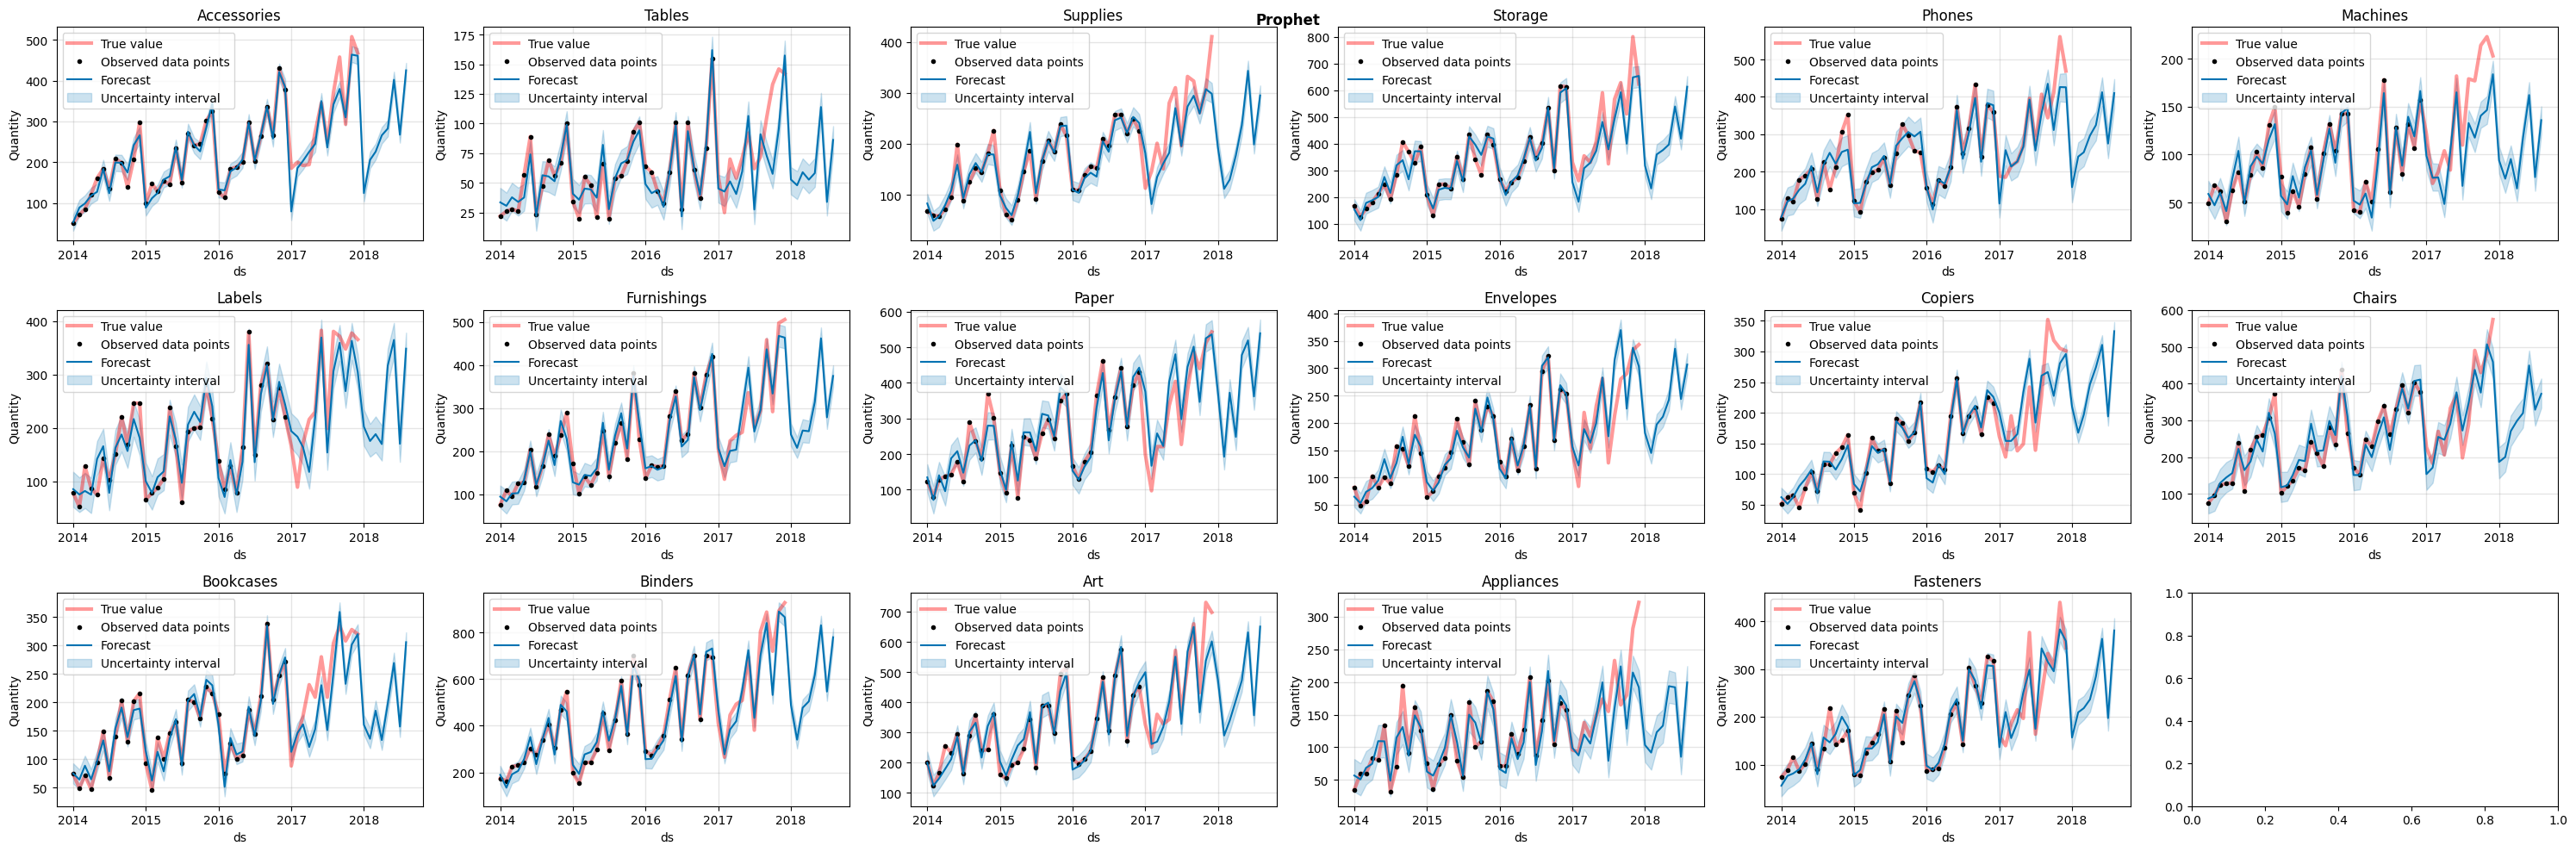

In [91]:
from tqdm import tqdm

fig, axes = plt.subplots(len(cats) // 6 + (len(cats) % 6 != 0) , 6, figsize=(30, 10))

for subcategory, ax in zip(cats, axes.flatten()):
    model = Prophet(
        growth="linear",
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative'
    )
    model.fit(prophet_dfs[subcategory], algorithm='newton')
    n = 20
    future = model.make_future_dataframe(periods=n, freq='MS')
    forecast = model.predict(future)
    sns.lineplot(
        data=info[info['sub-category'] == subcategory],
        x=ts_column,
        y='quantity',
        ax=ax,
        label='True value',
        color='red',
        linewidth=3,
        alpha=0.4
    )
    model.plot(cat_to_forecast[subcategory], ax=ax, include_legend=True)
    ax.legend()
    ax.set_title(subcategory)
    ax.set_ylabel('Quantity')

plt.tight_layout()
plt.suptitle('Prophet', weight='bold')
plt.show()

In [93]:
results.mean()

train_mae     15.926044
train_mape     0.109888
train_rmse    57.054060
test_mae      45.629011
test_mape      0.186759
test_rmse     57.054060
dtype: float64

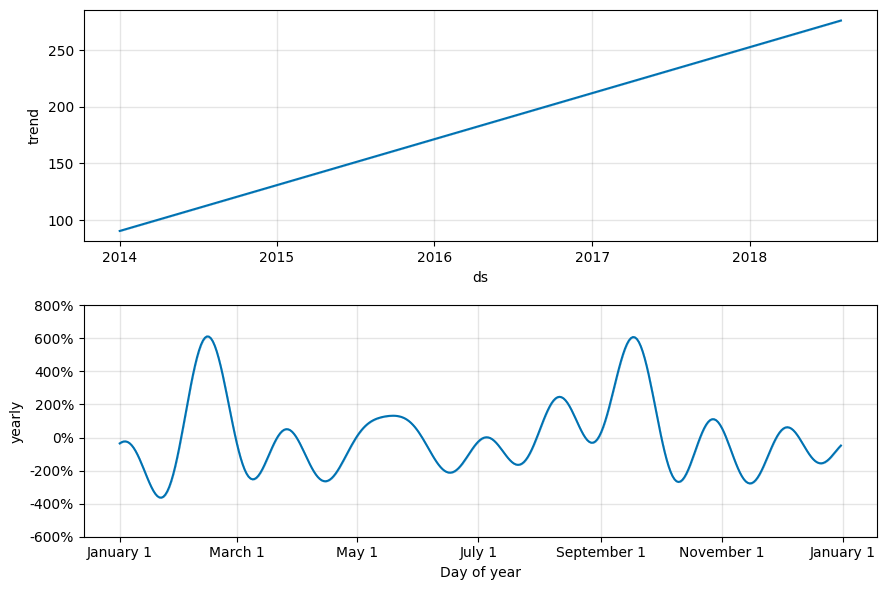

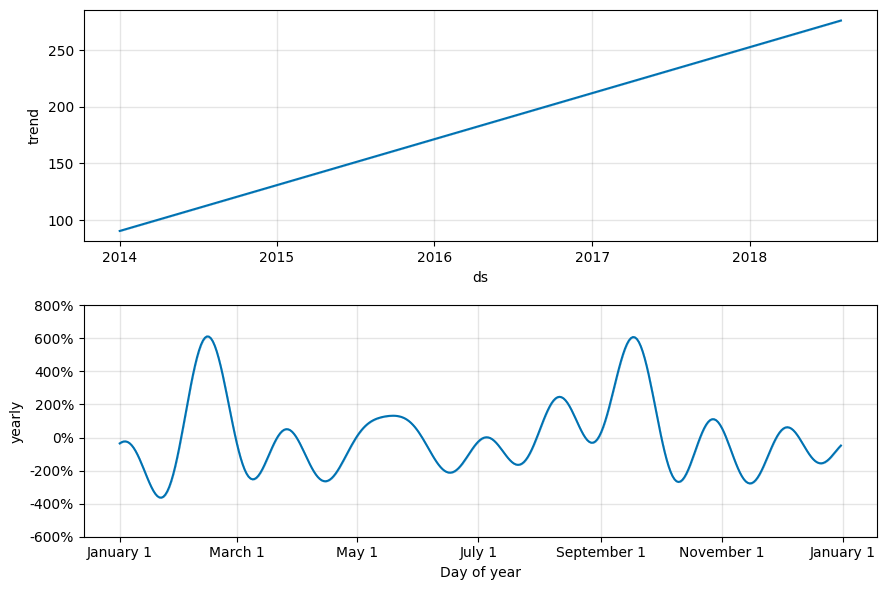

In [94]:
model.plot_components(forecast)
